# Generic Trend Model

This notebook will focus on developing a simple trend following model based originally on *Tail Protection for Long Investors: Trend Convexity at Work*

# Packages

In [67]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.simplefilter("ignore", FutureWarning)

# Collecting Data

In [29]:
root_path   = os.getcwd()
data_path   = os.path.join(root_path, "data")
signal_path = os.path.join(data_path, "GenericSignal", "GenericSignal.parquet")
fut_path    = os.path.join(data_path, "FuturesData", "PrepFuturesPX.parquet")
trend_path  = os.path.join(data_path, "Benchmarks", "TrendIndices.parquet")
ticker_path = os.path.join(data_path, "TickerGuide.xlsx")

In [4]:
vol_target = 0.1

In [5]:
df_signal = (pd.read_parquet(
    path = signal_path, engine = "pyarrow").
    pivot(index = "date", columns = "ticker", values = "signal").
    shift().
    reset_index().
    melt(id_vars = "date", value_name = "lag_signal").
    dropna())

In [6]:
df_rtn = (pd.read_parquet(
    path = fut_path, engine = "pyarrow").
    pivot(index = "date", columns = "ticker", values = "px_val").
    pct_change().
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna())

In [7]:
df_ticker_guide = (pd.read_excel(
    io = ticker_path)
    [["Front", "group"]].
    drop_duplicates().
    rename(columns = {"Front": "ticker"}).
    assign(ticker = lambda x: x.ticker.str.lower().str.strip().str.replace(" 1", "1").str.replace(" ", "_")))

In [37]:
df_sg = (pd.read_parquet(
    path = trend_path, engine = "pyarrow").
    query("security == 'NEIXCTAT Index'").
    assign(date = lambda x: pd.to_datetime(x.date).dt.date).
    set_index("date")
    [["PX_LAST"]].
    sort_index().
    pct_change().
    rename(columns = {"PX_LAST": "sg_trend"}))

# Backtesting Generic 100d EWMA Trend Model

In [8]:
df_signal_rtn = (df_signal.merge(
    right = df_rtn, how = "inner", on = ["date", "ticker"]).
    assign(signal_rtn = lambda x: np.sign(x.lag_signal) * x.rtn).
    merge(right = df_ticker_guide, how = "inner", on = ["ticker"]))

In [9]:
df_combo = (df_signal_rtn.pivot(
    index = "date", columns = "ticker", values = "signal_rtn").
    apply(lambda x: x * (vol_target / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 5, np.nan, x)).
    mean(axis = 1).
    to_frame(name = "combo"))

In [51]:
df_asset = (df_signal_rtn.pivot(
    index = "date", columns = ["group", "ticker"], values = "signal_rtn").
    apply(lambda x: x * (vol_target / (x.ewm(span = 100, adjust = False).std() * np.sqrt(252)))).
    apply(lambda x: np.where(np.abs(x) > 1, np.nan, x)).
    reset_index().
    melt(id_vars = [("date", "")]).
    rename(columns = {("date", ""): "date"}).
    dropna().
    drop(columns = ["ticker"]).
    groupby(["date", "group"]).
    agg("mean").
    reset_index().
    pivot(index = "date", columns = "group", values = "value"))

In [52]:
renamer = {
    "combo"            : "All",
    "commodity"        : "Commod",
    "crypto"           : "Crypto",
    "currency"         : "FX",
    "equity"           : "Equity",
    "fixed_income"     : "Bonds",
    "stir"             : "STIR",
    "sg_trend"         : "SocGen",
    "equity_volatility": "Volatility"}

In [53]:
df_combined = (df_combo.merge(
    right = df_asset, how = "inner", on = ["date"]).
    merge(right = df_sg, how = "inner", on = ["date"]).
    rename(columns = renamer))

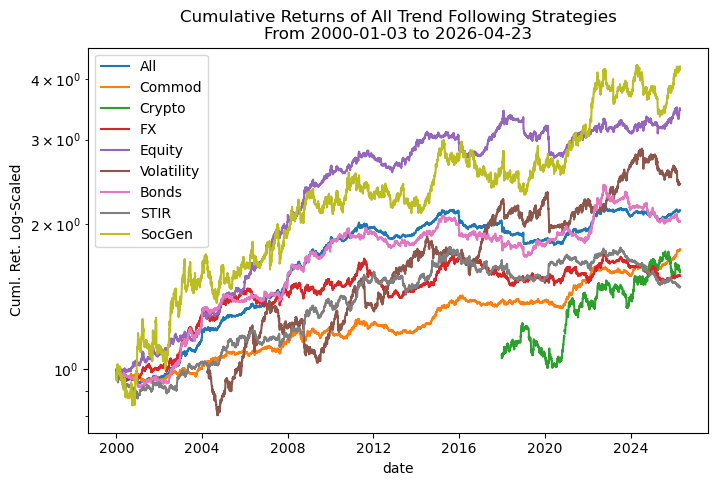

In [57]:
(df_combined.apply(
    lambda x: np.cumprod(1 + x)).
    plot(
        figsize = (8,5),
        logy    = True,
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = "Cumulative Returns of All Trend Following Strategies\nFrom {} to {}".format(
            df_combined.index.min(),
            df_combined.index.max())))
plt.show()

In [63]:
(df_combined.agg(
    lambda x: x.mean() / x.std() * np.sqrt(252)).
    to_frame(name = "Sharpe").
    T.
    apply(lambda x: np.round(x,3)))

,All,Commod,Crypto,FX,Equity,Volatility,Bonds,STIR,SocGen
Sharpe,0.83,0.67,0.647,0.349,0.855,0.504,0.541,0.312,0.484


In [86]:
(df_combined.reset_index().melt(
    id_vars = ["date", "SocGen"]).
    dropna().
    drop(columns = ["date"]).
    groupby("variable").
    agg("corr")
    ["value"].
    to_frame(name = "correlation").
    query("correlation != 1").
    reset_index().
    rename(columns = {
        "variable"   : "Asset Class",
        "correlation": "Corr"}).
    drop(columns = ["level_1"]).
    set_index("Asset Class").
    T)

Asset Class,All,Bonds,Commod,Crypto,Equity,FX,STIR,Volatility
Corr,0.523426,0.404368,0.433318,0.083911,0.396399,0.445067,0.208307,0.269589


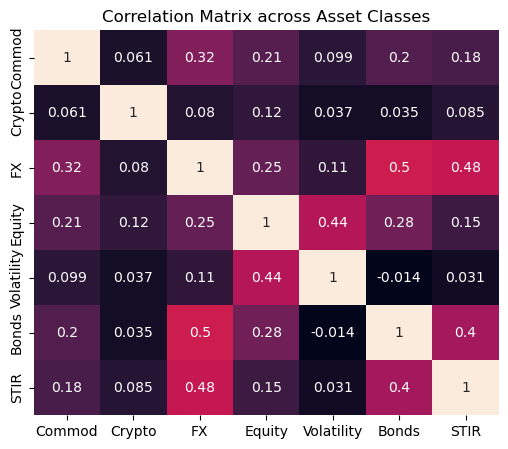

In [87]:
df_corr = df_combined.drop(columns = ["All", "SocGen"]).corr()
_, axes = plt.subplots(figsize = (6,5))

sns.heatmap(
    ax    = axes,
    data  = df_corr,
    annot = True,
    cbar  = False)

axes.set_title("Correlation Matrix across Asset Classes")
plt.show()